## **Sistem Pendukung Keputusan Prediktif Berbasis Machine Learning Pada Employee Attrition**

Disusun Oleh Kelompok 3 - SISTEM PENDUKUNG KEPUTUSAN (SI-D)

Nama :
- Novi Maharani Br Surbakti (NIM 235150400111011)
- Iftina Dewi Anisa Damayanti (NIM 235150407111003)



Dataset : https://www.kaggle.com/datasets/patelprashant/employee-attrition

Definisi masalah : "Mengidentifikasi karyawan yang berpotensi mengundurkan diri (attrition) dalam waktu dekat"

In [ ]:
# ============================================================
# TAHAP 1: IMPORT LIBRARY & DEFINISI MASALAH
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)

print("=" * 55)
print("  DSS PREDIKSI EMPLOYEE ATTRITION")
print("  Metode  : Random Forest Classifier")
print("  Masalah : Apakah karyawan ini berpotensi")
print("            mengundurkan diri (attrition)?")
print("=" * 55)

  DSS PREDIKSI EMPLOYEE ATTRITION
  Metode  : Random Forest Classifier
  Masalah : Apakah karyawan ini berpotensi
            mengundurkan diri (attrition)?


In [ ]:
import pandas as pd
print("Memuat file CSV dari Google Drive...")
file_id = "13X5vbiNiJnAzafDdqLV7F2ddYUzXtIyf"
url = f"https://drive.google.com/uc?id={file_id}"

df_raw = pd.read_csv(url)

print("\nFile berhasil dimuat")
print(f"Shape   : {df_raw.shape[0]} baris  x  {df_raw.shape[1]} kolom")
print(f"Kolom   : {list(df_raw.columns)}")
print("\n5 baris pertama:")
df_raw.head()

# ============================================================
# TAHAP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("=" * 55)
print("  2.1  INFORMASI DASAR DATASET")
print("=" * 55)

print(f"\nJumlah baris   : {df_raw.shape[0]}")
print(f"Jumlah kolom   : {df_raw.shape[1]}")
print(f"\nMissing values per kolom:")
missing = df_raw.isnull().sum()
missing_total = missing.sum()

if missing_total == 0:
    print("  → Tidak ada missing values pada seluruh kolom ✓")
else:
    print(missing[missing > 0].to_frame(name='Jumlah Missing'))
    print(f"\nTotal missing values: {missing_total}")

print(f"\nTipe data:")
print(df_raw.dtypes.to_string())

Memuat file CSV dari Google Drive...

File berhasil dimuat
Shape   : 1470 baris  x  35 kolom
Kolom   : ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

5 baris pertama:
  2.1  INFORMASI DASAR DATASET

Jumlah baris   : 1470
Jumlah kolom   : 35

Missing values per kolom:
  → Tidak ada missing values pada seluruh kolom ✓

Tipe data:
Age                          int64
Attrition                   object
BusinessTravel             

  2.2  DISTRIBUSI TARGET: Attrition
           Jumlah  Persen (%)
Attrition                    
No           1233       83.88
Yes           237       16.12


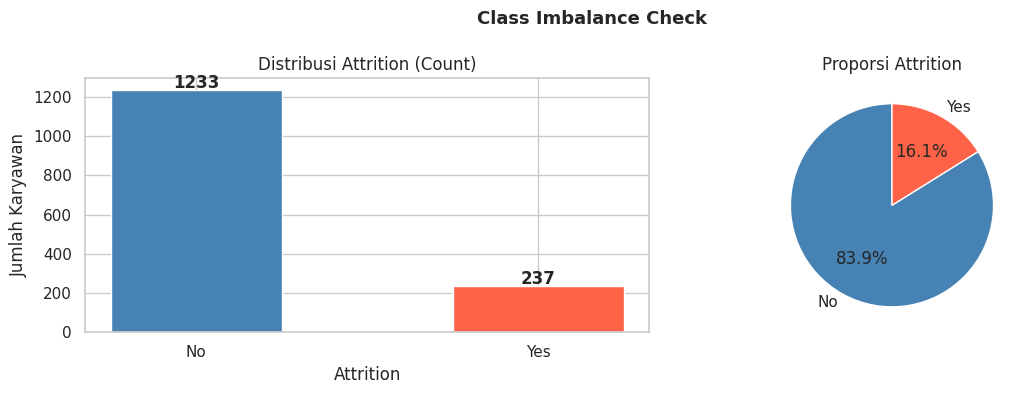


⚠️  Dataset IMBALANCED → akan ditangani dengan class_weight='balanced' pada model


In [ ]:

print("=" * 55)
print("  2.2  DISTRIBUSI TARGET: Attrition")
print("=" * 55)

target_count = df_raw['Attrition'].value_counts()
target_pct   = df_raw['Attrition'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Jumlah' : target_count,
    'Persen (%)' : target_pct.round(2)
})
print(summary)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(target_count.index, target_count.values,
            color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
axes[0].set_title('Distribusi Attrition (Count)')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Jumlah Karyawan')
for i, v in enumerate(target_count.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(target_count.values, labels=target_count.index,
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporsi Attrition')

plt.suptitle('Class Imbalance Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️  Dataset IMBALANCED → akan ditangani dengan class_weight='balanced' pada model")

  2.3  DISTRIBUSI FITUR NUMERIK
Kolom konstan ditemukan (akan di-drop nanti): ['EmployeeCount', 'StandardHours']

Statistik deskriptif fitur numerik:
                           count     mean     std     min     25%      50%      75%      max
Age                      1470.00    36.92    9.14   18.00   30.00    36.00    43.00    60.00
DailyRate                1470.00   802.49  403.51  102.00  465.00   802.00  1157.00  1499.00
DistanceFromHome         1470.00     9.19    8.11    1.00    2.00     7.00    14.00    29.00
Education                1470.00     2.91    1.02    1.00    2.00     3.00     4.00     5.00
EmployeeNumber           1470.00  1024.87  602.02    1.00  491.25  1020.50  1555.75  2068.00
EnvironmentSatisfaction  1470.00     2.72    1.09    1.00    2.00     3.00     4.00     4.00
HourlyRate               1470.00    65.89   20.33   30.00   48.00    66.00    83.75   100.00
JobInvolvement           1470.00     2.73    0.71    1.00    2.00     3.00     3.00     4.00
JobLevel     

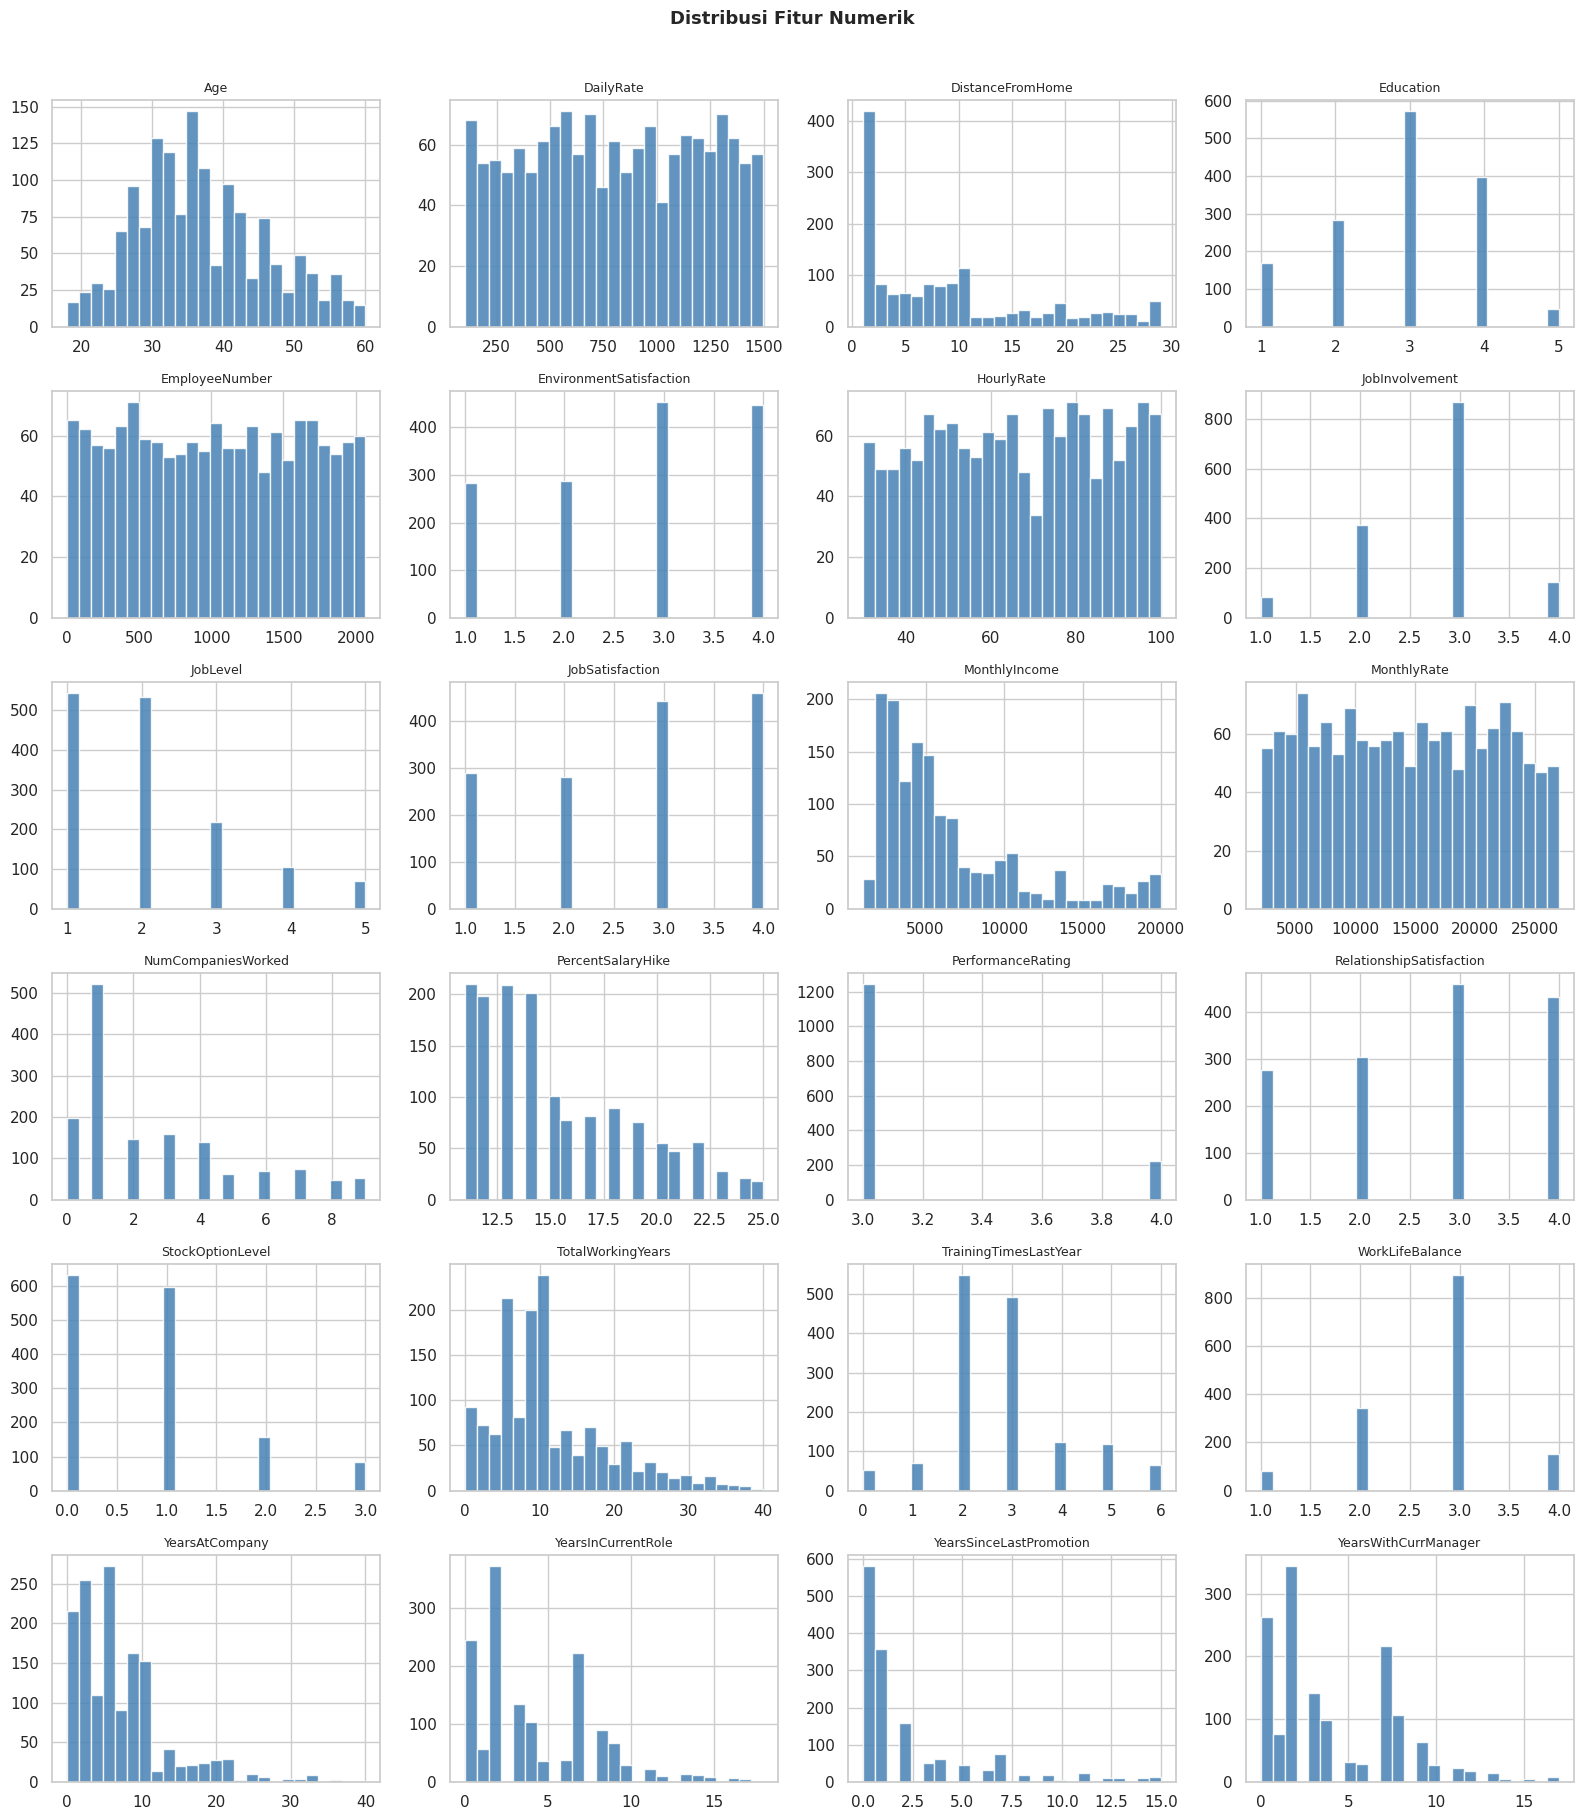

In [ ]:

print("=" * 55)
print("  2.3  DISTRIBUSI FITUR NUMERIK")
print("=" * 55)

num_cols = df_raw.select_dtypes(include='number').columns.tolist()

# Hapus kolom konstan (tidak informatif)
const_cols = [c for c in num_cols if df_raw[c].nunique() == 1]
num_cols    = [c for c in num_cols if c not in const_cols]
print(f"Kolom konstan ditemukan (akan di-drop nanti): {const_cols}")
print(f"\nStatistik deskriptif fitur numerik:")
print(df_raw[num_cols].describe().T.to_string())

# Histogram
n = len(num_cols)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row,
                         figsize=(cols_per_row * 4, rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_raw[col], bins=25, color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

  2.4  DETEKSI OUTLIER (IQR Method)
                  Fitur  Outlier  Persen (%)
  TrainingTimesLastYear      238       16.19
      PerformanceRating      226       15.37
          MonthlyIncome      114        7.76
YearsSinceLastPromotion      107        7.28
         YearsAtCompany      104        7.07
       StockOptionLevel       85        5.78
      TotalWorkingYears       63        4.29
     NumCompaniesWorked       52        3.54
     YearsInCurrentRole       21        1.43
   YearsWithCurrManager       14        0.95


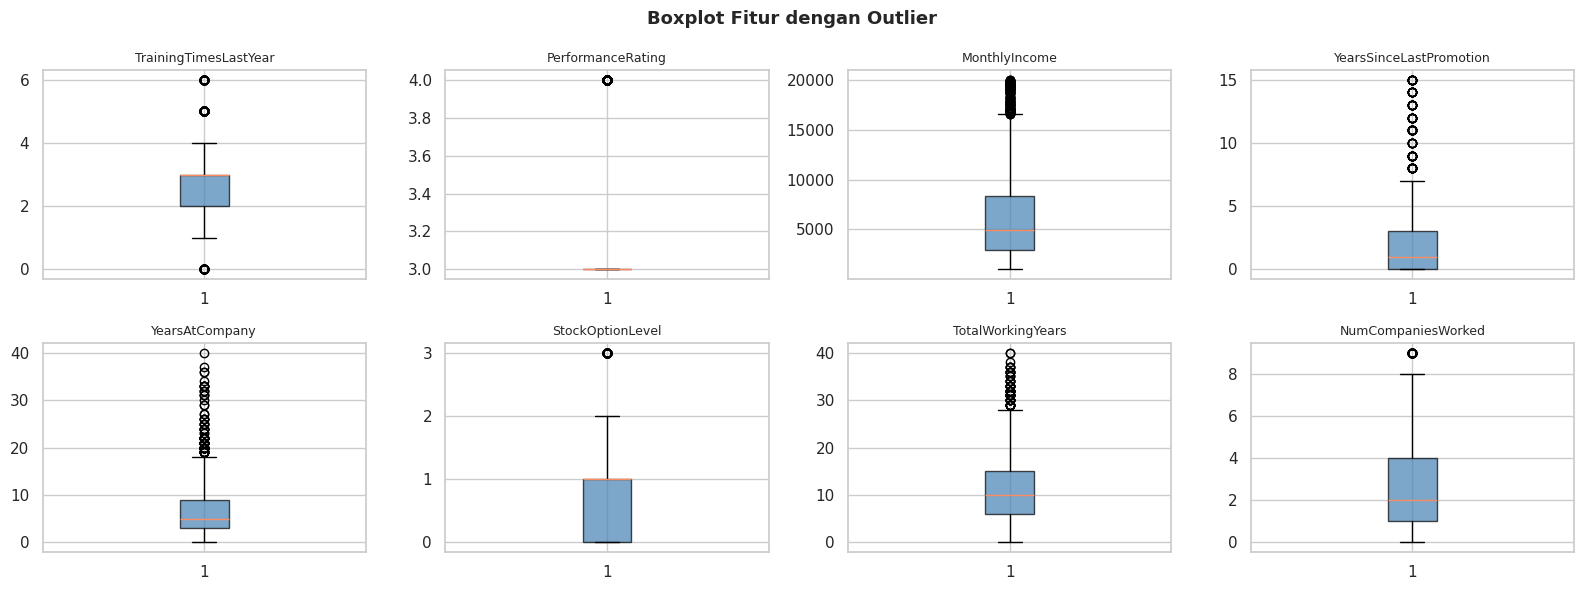

In [ ]:

print("=" * 55)
print("  2.4  DETEKSI OUTLIER (IQR Method)")
print("=" * 55)

outlier_info = []
for col in num_cols:
    Q1  = df_raw[col].quantile(0.25)
    Q3  = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_raw[col] < Q1 - 1.5 * IQR) |
             (df_raw[col] > Q3 + 1.5 * IQR)).sum()
    outlier_info.append({'Fitur': col, 'Outlier': n_out,
                         'Persen (%)': round(n_out / len(df_raw) * 100, 2)})

df_outlier = pd.DataFrame(outlier_info).sort_values('Outlier', ascending=False)
print(df_outlier[df_outlier['Outlier'] > 0].to_string(index=False))

# Boxplot fitur dengan outlier terbanyak
top_out = df_outlier[df_outlier['Outlier'] > 0].head(8)['Fitur'].tolist()
if top_out:
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    axes = axes.flatten()
    for i, col in enumerate(top_out):
        axes[i].boxplot(df_raw[col].dropna(), patch_artist=True,
                        boxprops=dict(facecolor='steelblue', alpha=0.7))
        axes[i].set_title(col, fontsize=9)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Boxplot Fitur dengan Outlier', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

  2.5  KORELASI FITUR NUMERIK


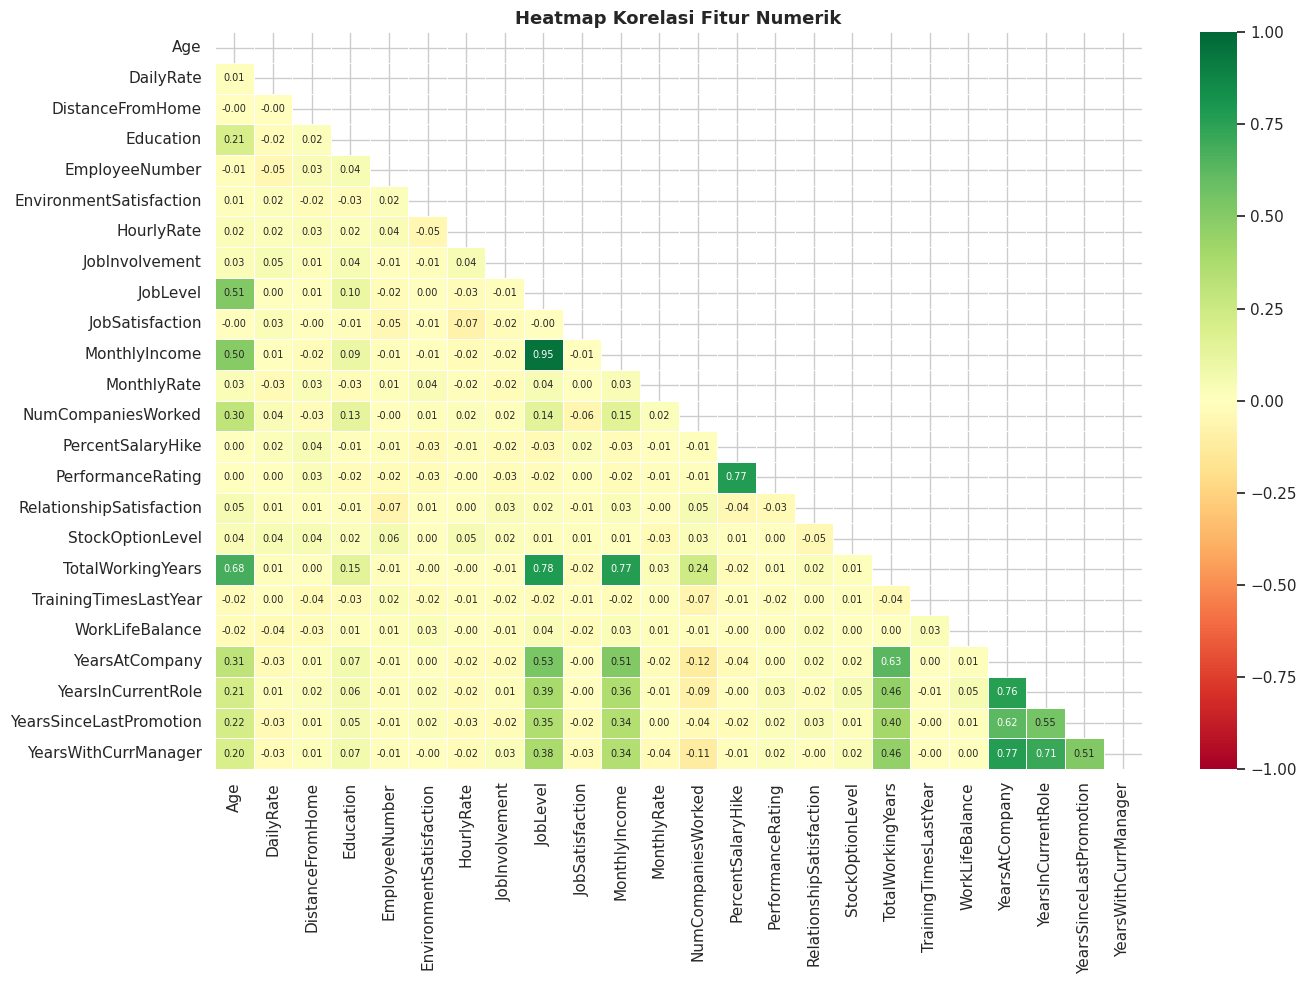


  2.6  FITUR KATEGORIK vs ATTRITION
Fitur kategorik: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


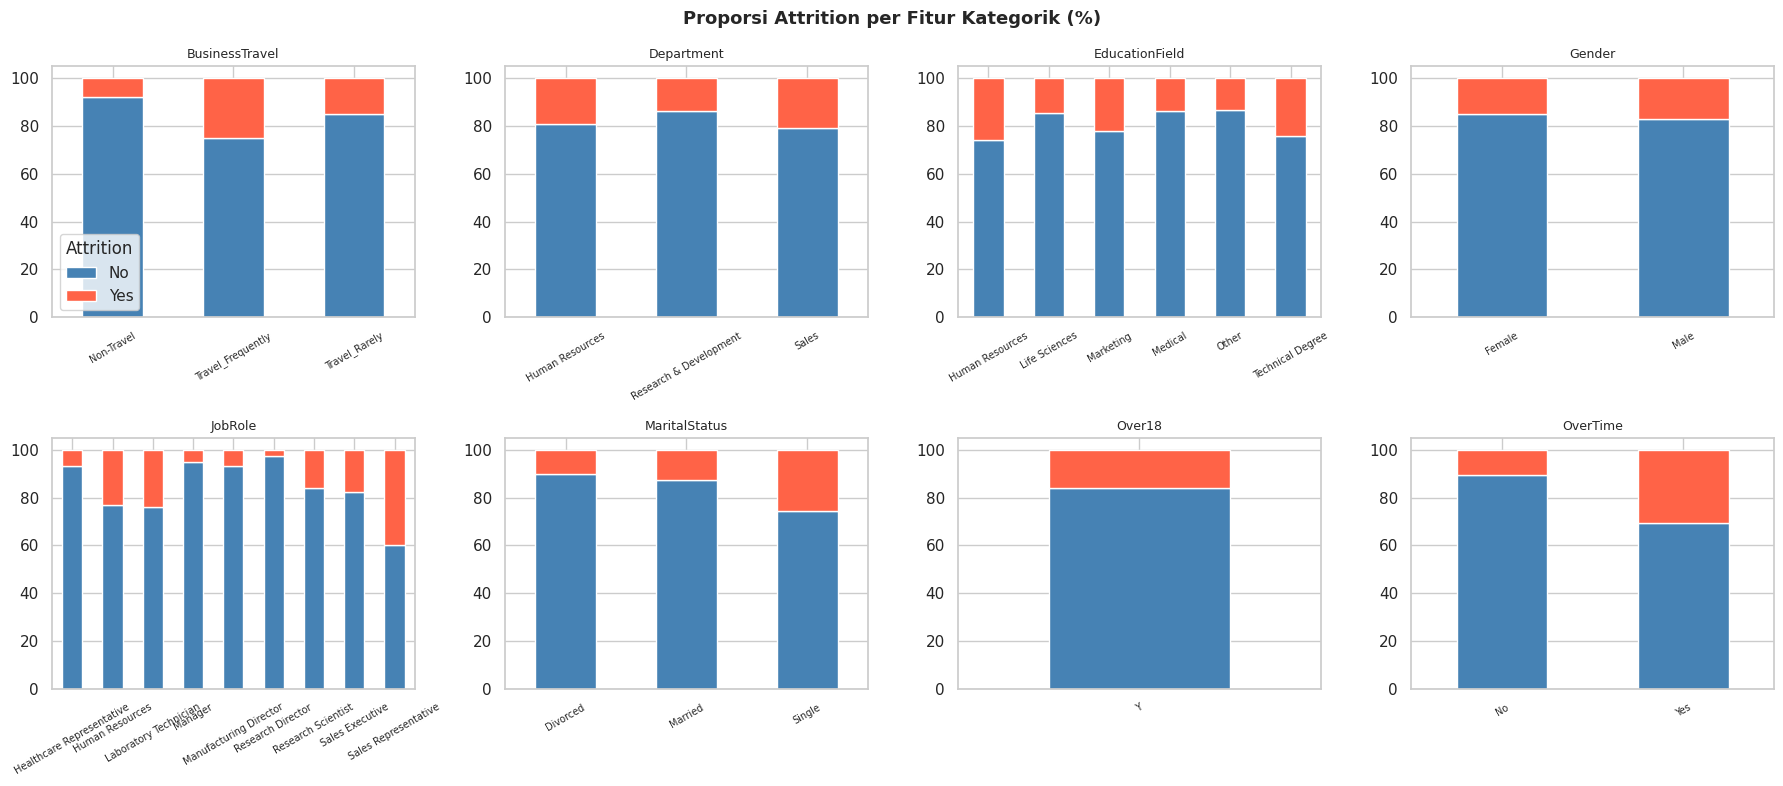


✅ EDA selesai. Lanjut ke Tahap 3: Preprocessing


In [ ]:

print("=" * 55)
print("  2.5  KORELASI FITUR NUMERIK")
print("=" * 55)

corr_matrix = df_raw[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5,
            annot_kws={'size': 7}, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Fitur Kategorik ──────────────────────────────────────
print("\n" + "=" * 55)
print("  2.6  FITUR KATEGORIK vs ATTRITION")
print("=" * 55)

cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Attrition')   # target dipisah
print(f"Fitur kategorik: {cat_cols}")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:8]):
    ct = df_raw.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=axes[i], stacked=True,
                color=['steelblue', 'tomato'], edgecolor='white', legend=(i == 0))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelrotation=30, labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Proporsi Attrition per Fitur Kategorik (%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ EDA selesai. Lanjut ke Tahap 3: Preprocessing")

In [ ]:
# ============================================================
# TAHAP 3: DATA PREPROCESSING
# ============================================================

print("=" * 55)
print("  3.1  IDENTIFIKASI KOLOM TIDAK BERGUNA")
print("=" * 55)

# Cek kolom dengan nilai unik hanya 1 (konstan)
const_cols = [col for col in df_raw.columns if df_raw[col].nunique() == 1]
print(f"Kolom konstan (semua nilai sama): {const_cols}")

# Cek detail
for col in const_cols:
    print(f"  → {col}: nilai = '{df_raw[col].unique()[0]}'")

# Kolom ID (tidak relevan untuk prediksi)
id_cols = ['EmployeeNumber']
print(f"\nKolom ID (tidak informatif): {id_cols}")

# Total yang akan di-drop
drop_cols = const_cols + id_cols
print(f"\nTotal kolom yang akan di-drop: {drop_cols}")

  3.1  IDENTIFIKASI KOLOM TIDAK BERGUNA
Kolom konstan (semua nilai sama): ['EmployeeCount', 'Over18', 'StandardHours']
  → EmployeeCount: nilai = '1'
  → Over18: nilai = 'Y'
  → StandardHours: nilai = '80'

Kolom ID (tidak informatif): ['EmployeeNumber']

Total kolom yang akan di-drop: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']


In [ ]:
print("=" * 55)
print("  3.2  DROP KOLOM & ENCODE TARGET")
print("=" * 55)

# Buat salinan agar df_raw tetap utuh
df = df_raw.drop(columns=drop_cols).copy()

# Encode target: Yes=1, No=0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print(f"Shape setelah drop  : {df.shape}")
print(f"Distribusi target   :")
print(df['Attrition'].value_counts().to_frame('Jumlah'))
print(f"\nKolom tersisa: {list(df.columns)}")

  3.2  DROP KOLOM & ENCODE TARGET
Shape setelah drop  : (1470, 31)
Distribusi target   :
           Jumlah
Attrition        
0            1233
1             237

Kolom tersisa: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
print("=" * 55)
print("  3.3  ENCODING FITUR KATEGORIK")
print("=" * 55)

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Kolom kategorik yang akan di-encode: {cat_cols}")
print()

# Label Encoding untuk kolom binary (2 nilai unik)
from sklearn.preprocessing import LabelEncoder

binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
multi_cols  = [col for col in cat_cols if df[col].nunique() > 2]

print(f"Binary encoding  (2 nilai) : {binary_cols}")
print(f"One-Hot encoding (>2 nilai): {multi_cols}")

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"  → {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-Hot Encoding untuk kolom dengan >2 nilai unik
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f"\nShape setelah encoding: {df.shape}")
print(f"Tipe data setelah encoding:")
print(df.dtypes.value_counts())

  3.3  ENCODING FITUR KATEGORIK
Kolom kategorik yang akan di-encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Binary encoding  (2 nilai) : ['Gender', 'OverTime']
One-Hot encoding (>2 nilai): ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
  → Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  → OverTime: {'No': np.int64(0), 'Yes': np.int64(1)}

Shape setelah encoding: (1470, 45)
Tipe data setelah encoding:
int64    26
bool     19
Name: count, dtype: int64


In [ ]:
print("=" * 55)
print("  3.4  FEATURE SELECTION")
print("=" * 55)

# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f"Jumlah fitur awal : {X.shape[1]}")

# Hapus fitur dengan variance = 0 (jika ada sisa konstan setelah encoding)
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
selector.fit(X)
low_var = X.columns[~selector.get_support()].tolist()

if low_var:
    print(f"Fitur variance=0 ditemukan & di-drop: {low_var}")
    X = X[X.columns[selector.get_support()]]
else:
    print("Tidak ada fitur dengan variance=0 ✓")

print(f"Jumlah fitur akhir: {X.shape[1]}")
print(f"\nDaftar fitur final:")
print(list(X.columns))

  3.4  FEATURE SELECTION
Jumlah fitur awal : 44
Tidak ada fitur dengan variance=0 ✓
Jumlah fitur akhir: 44

Daftar fitur final:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Direc

In [ ]:
print("=" * 55)
print("  3.5  TRAIN / TEST SPLIT")
print("=" * 55)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y       # pastikan proporsi imbalance terjaga
)

print(f"Total data        : {len(X)}")
print(f"Data training     : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Data testing      : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)")

print(f"\nDistribusi target di training set:")
print(y_train.value_counts().to_frame('Jumlah'))
print(f"\nDistribusi target di testing set:")
print(y_test.value_counts().to_frame('Jumlah'))

print("\n✅ Preprocessing selesai. Lanjut ke Tahap 4: Model Building")

  3.5  TRAIN / TEST SPLIT
Total data        : 1470
Data training     : 1176 (80%)
Data testing      : 294  (20%)

Distribusi target di training set:
           Jumlah
Attrition        
0             986
1             190

Distribusi target di testing set:
           Jumlah
Attrition        
0             247
1              47

✅ Preprocessing selesai. Lanjut ke Tahap 4: Model Building


In [ ]:
# ============================================================
# TAHAP 4: MODEL BUILDING
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings('ignore')

print("Library model berhasil diimport ✓")

# ── Fungsi evaluasi reusable ─────────────────────────────────
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    result = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred),  4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall'   : round(recall_score(y_te, y_pred),    4),
        'F1-Score' : round(f1_score(y_te, y_pred),        4),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_proba),  4),
    }
    return result, model, y_pred, y_proba

Library model berhasil diimport ✓


In [ ]:
print("=" * 55)
print("  4.1  TRAINING MODEL")
print("=" * 55)

# Definisi model
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators  = 100,
        class_weight  = 'balanced',
        random_state  = 42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight  = 'balanced',
        random_state  = 42
    ),
    'Logistic Regression': LogisticRegression(
        class_weight  = 'balanced',
        max_iter      = 1000,
        random_state  = 42
    ),
}

# Training & evaluasi semua model
results    = []
trained    = {}
preds      = {}
probas     = {}

for name, model in models.items():
    print(f"  Training {name}...", end=" ")
    res, fitted, y_pred, y_proba = evaluate_model(
        name, model, X_train, X_test, y_train, y_test
    )
    results.append(res)
    trained[name] = fitted
    preds[name]   = y_pred
    probas[name]  = y_proba
    print("✓")

print("\nSemua model selesai ditraining ✓")

  4.1  TRAINING MODEL
  Training Random Forest... ✓
  Training Decision Tree... ✓
  Training Logistic Regression... ✓

Semua model selesai ditraining ✓


In [ ]:
# ============================================================
# TAHAP 5: MODEL COMPARISON
# ============================================================

print("=" * 55)
print("  5.1  TABEL PERBANDINGAN MODEL")
print("=" * 55)

df_results = pd.DataFrame(results).set_index('Model')
print(df_results.to_string())

# Highlight model terbaik per metrik
print("\nModel terbaik per metrik:")
for col in df_results.columns:
    best = df_results[col].idxmax()
    print(f"  {col:<12}: {best} ({df_results.loc[best, col]:.4f})")

  5.1  TABEL PERBANDINGAN MODEL
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Random Forest            0.83       0.33    0.06      0.11     0.75
Decision Tree            0.79       0.33    0.30      0.31     0.59
Logistic Regression      0.69       0.29    0.66      0.40     0.73

Model terbaik per metrik:
  Accuracy    : Random Forest (0.8299)
  Precision   : Random Forest (0.3333)
  Recall      : Logistic Regression (0.6596)
  F1-Score    : Logistic Regression (0.4026)
  ROC-AUC     : Random Forest (0.7453)


  5.2  VISUALISASI PERBANDINGAN METRIK


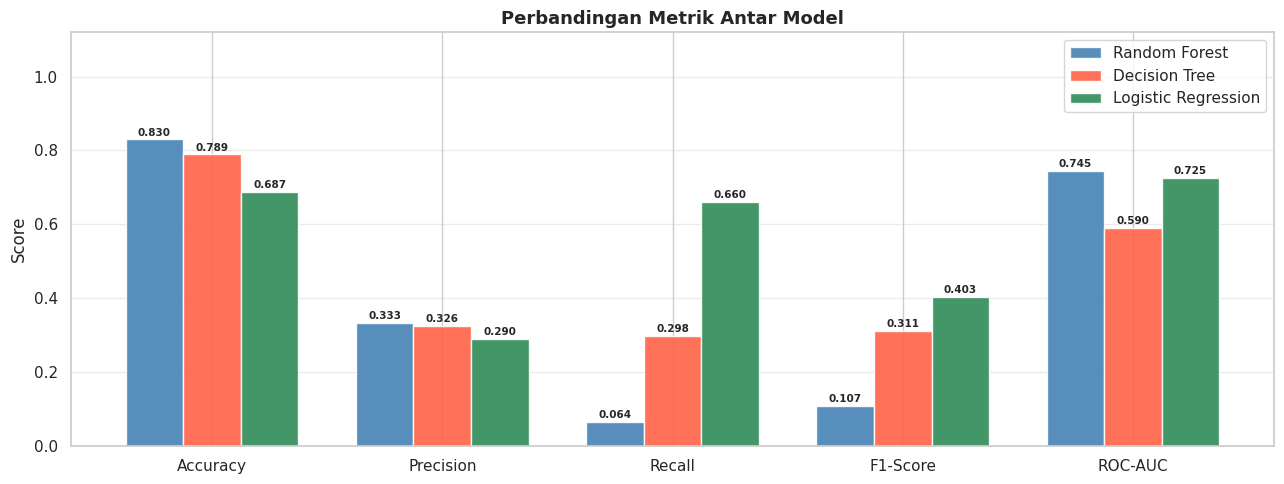

In [ ]:
print("=" * 55)
print("  5.2  VISUALISASI PERBANDINGAN METRIK")
print("=" * 55)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['steelblue', 'tomato', 'seagreen']

fig, ax = plt.subplots(figsize=(13, 5))

for i, (name, row) in enumerate(df_results.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width,
                  label=name, color=colors[i],
                  edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik Antar Model', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

  5.3  CONFUSION MATRIX


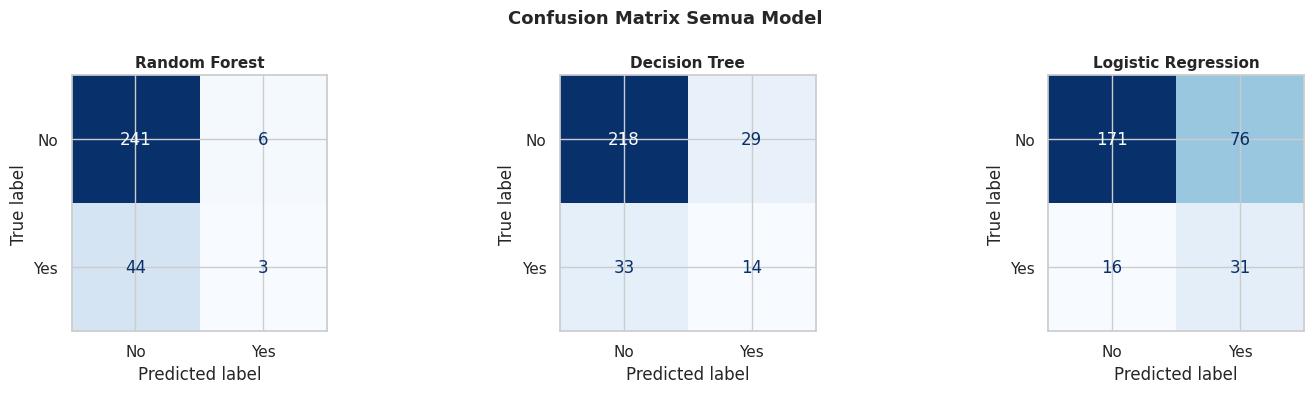

In [ ]:
print("=" * 55)
print("  5.3  CONFUSION MATRIX")
print("=" * 55)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix Semua Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

  5.4  ROC CURVE


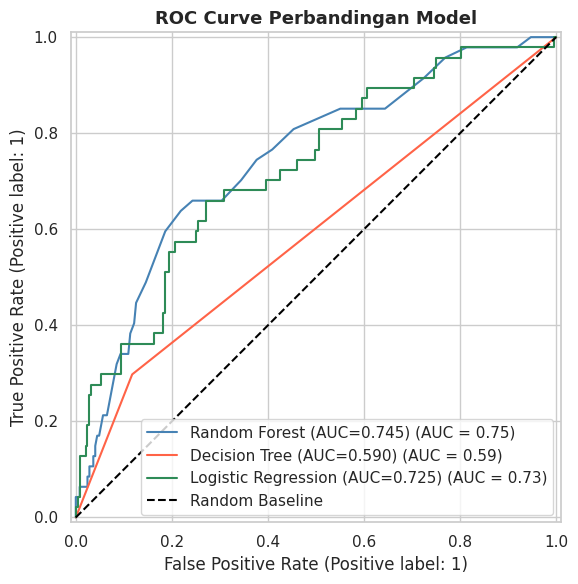


  5.5  CLASSIFICATION REPORT — Logistic Regression
              precision    recall  f1-score   support

No Attrition       0.91      0.69      0.79       247
   Attrition       0.29      0.66      0.40        47

    accuracy                           0.69       294
   macro avg       0.60      0.68      0.60       294
weighted avg       0.81      0.69      0.73       294



In [ ]:
print("=" * 55)
print("  5.4  ROC CURVE")
print("=" * 55)

fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['steelblue', 'tomato', 'seagreen']

for (name, y_proba), color in zip(probas.items(), colors_roc):
    RocCurveDisplay.from_predictions(
        y_test, y_proba,
        name=f"{name} (AUC={roc_auc_score(y_test, y_proba):.3f})",
        ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
ax.set_title('ROC Curve Perbandingan Model', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ── Classification Report model terbaik ─────────────────────
best_model_name = df_results['F1-Score'].idxmax()
print(f"\n{'=' * 55}")
print(f"  5.5  CLASSIFICATION REPORT — {best_model_name}")
print(f"{'=' * 55}")
print(classification_report(y_test, preds[best_model_name],
                             target_names=['No Attrition', 'Attrition']))

  5.6  FEATURE IMPORTANCE (Random Forest)


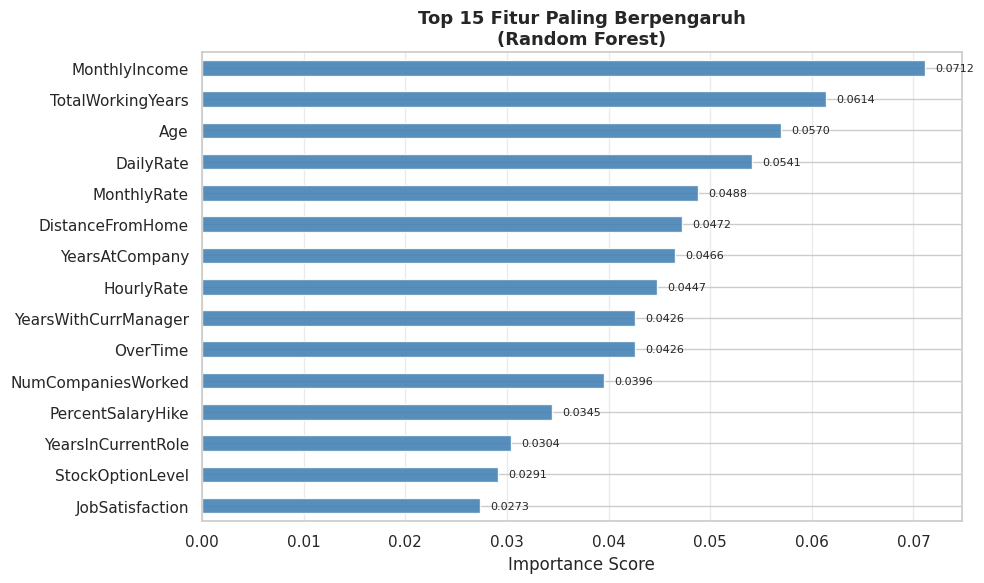


✅ Model Building & Comparison selesai!
   Model terbaik berdasarkan F1-Score: Logistic Regression


In [ ]:
print("=" * 55)
print("  5.6  FEATURE IMPORTANCE (Random Forest)")
print("=" * 55)

rf_model   = trained['Random Forest']
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.9)
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Fitur Paling Berpengaruh\n(Random Forest)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.4)

for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✅ Model Building & Comparison selesai!")
print(f"   Model terbaik berdasarkan F1-Score: {best_model_name}")

In [ ]:
# ============================================================
# TAHAP 6: PERSIAPAN DASHBOARD DSS
# ============================================================

import pickle, os

print("=" * 55)
print("  6.1  SIMPAN MODEL & KOMPONEN")
print("=" * 55)

# Buat folder
os.makedirs('dss_attrition', exist_ok=True)

# Simpan model terbaik (Random Forest)
with open('dss_attrition/model_rf.pkl', 'wb') as f:
    pickle.dump(trained['Random Forest'], f)

# Simpan nama kolom fitur (penting untuk input dashboard)
with open('dss_attrition/feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X_train.columns), f)

# Simpan df_raw untuk referensi nilai unik tiap kolom
with open('dss_attrition/df_raw.pkl', 'wb') as f:
    pickle.dump(df_raw, f)

print("File tersimpan:")
for f in os.listdir('dss_attrition'):
    size = os.path.getsize(f'dss_attrition/{f}')
    print(f"  → dss_attrition/{f}  ({size:,} bytes)")

  6.1  SIMPAN MODEL & KOMPONEN
File tersimpan:
  → dss_attrition/df_raw.pkl  (334,225 bytes)
  → dss_attrition/model_rf.pkl  (2,554,049 bytes)
  → dss_attrition/feature_columns.pkl  (987 bytes)


In [1]:
# ============================================================
# TAHAP 6.2  GENERATE app.py
# ============================================================

app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

# ── Load artefak ────────────────────────────────────────────
@st.cache_resource
def load_artifacts():
    with open("dss_attrition/model_rf.pkl", "rb") as f:
        model = pickle.load(f)
    with open("dss_attrition/feature_columns.pkl", "rb") as f:
        feature_cols = pickle.load(f)
    with open("dss_attrition/df_raw.pkl", "rb") as f:
        df_raw = pickle.load(f)
    return model, feature_cols, df_raw

model, feature_cols, df_raw = load_artifacts()

# ── Konfigurasi halaman ──────────────────────────────────────
st.set_page_config(
    page_title = "DSS Employee Attrition",
    page_icon  = "👥",
    layout     = "wide"
)

# ── Header ───────────────────────────────────────────────────
st.title("👥 Sistem Pendukung Keputusan")
st.subheader("Prediksi Employee Attrition — Random Forest")
st.markdown("---")

# ── Sidebar: Input Data Karyawan ────────────────────────────
st.sidebar.header("📋 Input Data Karyawan")

def user_input():
    age                      = st.sidebar.slider("Age", 18, 60, 30)
    monthly_income           = st.sidebar.number_input("Monthly Income", 1000, 20000, 5000, step=500)
    distance_from_home       = st.sidebar.slider("Distance From Home (km)", 1, 30, 10)
    years_at_company         = st.sidebar.slider("Years At Company", 0, 40, 5)
    years_in_role            = st.sidebar.slider("Years In Current Role", 0, 18, 3)
    years_since_promotion    = st.sidebar.slider("Years Since Last Promotion", 0, 15, 1)
    years_with_manager       = st.sidebar.slider("Years With Current Manager", 0, 17, 3)
    total_working_years      = st.sidebar.slider("Total Working Years", 0, 40, 8)
    num_companies            = st.sidebar.slider("Num Companies Worked", 0, 9, 2)
    training_times           = st.sidebar.slider("Training Times Last Year", 0, 6, 2)

    job_satisfaction         = st.sidebar.selectbox("Job Satisfaction (1=Low, 4=High)", [1,2,3,4], index=2)
    environment_satisfaction = st.sidebar.selectbox("Environment Satisfaction (1=Low, 4=High)", [1,2,3,4], index=2)
    work_life_balance        = st.sidebar.selectbox("Work Life Balance (1=Bad, 4=Best)", [1,2,3,4], index=2)
    job_involvement          = st.sidebar.selectbox("Job Involvement (1=Low, 4=High)", [1,2,3,4], index=2)
    job_level                = st.sidebar.selectbox("Job Level", [1,2,3,4,5], index=1)
    stock_option             = st.sidebar.selectbox("Stock Option Level", [0,1,2,3], index=1)
    performance_rating       = st.sidebar.selectbox("Performance Rating (3=Excellent, 4=Outstanding)", [3,4], index=0)
    education                = st.sidebar.selectbox("Education (1=Below College, 5=Doctor)", [1,2,3,4,5], index=2)
    percent_hike             = st.sidebar.slider("Percent Salary Hike", 11, 25, 14)

    overtime      = st.sidebar.selectbox("OverTime", ["Yes", "No"])
    gender        = st.sidebar.selectbox("Gender", ["Male", "Female"])
    marital       = st.sidebar.selectbox("Marital Status", ["Single", "Married", "Divorced"])
    travel        = st.sidebar.selectbox("Business Travel", ["Non-Travel", "Travel_Rarely", "Travel_Frequently"])
    department    = st.sidebar.selectbox("Department", ["Sales", "Research & Development", "Human Resources"])
    edu_field     = st.sidebar.selectbox("Education Field", ["Life Sciences", "Medical", "Marketing",
                                                              "Technical Degree", "Other", "Human Resources"])
    job_role      = st.sidebar.selectbox("Job Role", [
        "Sales Executive", "Research Scientist", "Laboratory Technician",
        "Manufacturing Director", "Healthcare Representative", "Manager",
        "Sales Representative", "Research Director", "Human Resources"
    ])

    daily_rate    = st.sidebar.slider("Daily Rate", 100, 1500, 800)
    hourly_rate   = st.sidebar.slider("Hourly Rate", 30, 100, 65)
    monthly_rate  = st.sidebar.slider("Monthly Rate", 2000, 27000, 14000, step=500)

    data = {
        "Age": age, "DailyRate": daily_rate, "DistanceFromHome": distance_from_home,
        "Education": education, "EmployeeCount": 1, "EnvironmentSatisfaction": environment_satisfaction,
        "HourlyRate": hourly_rate, "JobInvolvement": job_involvement, "JobLevel": job_level,
        "JobSatisfaction": job_satisfaction, "MonthlyIncome": monthly_income,
        "MonthlyRate": monthly_rate, "NumCompaniesWorked": num_companies,
        "Over18": "Y", "PercentSalaryHike": percent_hike, "PerformanceRating": performance_rating,
        "RelationshipSatisfaction": 3, "StandardHours": 80, "StockOptionLevel": stock_option,
        "TotalWorkingYears": total_working_years, "TrainingTimesLastYear": training_times,
        "WorkLifeBalance": work_life_balance, "YearsAtCompany": years_at_company,
        "YearsInCurrentRole": years_in_role, "YearsSinceLastPromotion": years_since_promotion,
        "YearsWithCurrManager": years_with_manager,
        "BusinessTravel": travel, "Department": department, "EducationField": edu_field,
        "Gender": gender, "JobRole": job_role, "MaritalStatus": marital, "OverTime": overtime,
    }
    return pd.DataFrame([data])

input_df = user_input()

# ── Preprocessing input (sama seperti training) ──────────────
def preprocess_input(raw_df):
    df = raw_df.copy()

    # Drop kolom yang di-drop saat training
    drop_cols = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    # Binary encoding
    binary_map = {"OverTime": {"Yes": 1, "No": 0},
                  "Gender":   {"Male": 1, "Female": 0}}
    for col, mapping in binary_map.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    # One-Hot encoding
    multi_cols = ["BusinessTravel", "Department", "EducationField",
                  "JobRole", "MaritalStatus"]
    df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

    # Align kolom dengan training
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0
    df = df[feature_cols]
    return df

processed = preprocess_input(input_df)

# ── Prediksi ─────────────────────────────────────────────────
prob        = model.predict_proba(processed)[0]
pred_label  = model.predict(processed)[0]
prob_yes    = prob[1]
prob_no     = prob[0]

# ── Tampilan Hasil ───────────────────────────────────────────
col1, col2, col3 = st.columns(3)

with col1:
    st.metric("🎯 Prediksi", "ATTRITION ⚠️" if pred_label == 1 else "TETAP ✅")

with col2:
    st.metric("📊 Probabilitas Attrition", f"{prob_yes*100:.1f}%")

with col3:
    st.metric("📊 Probabilitas Tetap", f"{prob_no*100:.1f}%")

st.markdown("---")

# ── Gauge Chart ──────────────────────────────────────────────
col_a, col_b = st.columns([1, 1])

with col_a:
    st.subheader("📈 Tingkat Risiko Attrition")

    color = "green" if prob_yes < 0.4 else ("orange" if prob_yes < 0.7 else "red")
    level = "🟢 RENDAH" if prob_yes < 0.4 else ("🟡 SEDANG" if prob_yes < 0.7 else "🔴 TINGGI")

    fig, ax = plt.subplots(figsize=(5, 0.6))
    ax.barh(["Risiko"], [prob_yes], color=color, height=0.4)
    ax.barh(["Risiko"], [1 - prob_yes], left=[prob_yes],
            color="lightgray", height=0.4)
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.4, 0.7, 1.0])
    ax.set_xticklabels(["0%", "40%", "70%", "100%"])
    ax.set_title(f"Probabilitas Attrition: {prob_yes*100:.1f}%  →  {level}")
    ax.spines[["top","right","left"]].set_visible(False)
    st.pyplot(fig)

with col_b:
    st.subheader("🔍 Rekomendasi Keputusan")
    if prob_yes < 0.4:
        st.success("✅ Karyawan cenderung **TIDAK akan resign**. Pertahankan kondisi kerja saat ini.")
    elif prob_yes < 0.7:
        st.warning("⚠️ Karyawan berisiko **SEDANG**. Lakukan review kepuasan kerja dan pertimbangkan kenaikan gaji atau promosi.")
    else:
        st.error("🚨 Karyawan berisiko **TINGGI** untuk resign. Segera lakukan intervensi: diskusi karier, penyesuaian kompensasi, atau pengurangan lembur.")

st.markdown("---")

# ── Feature Importance ────────────────────────────────────────
st.subheader("📊 Faktor Paling Berpengaruh terhadap Attrition")

importances = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False).head(10)

fig2, ax2 = plt.subplots(figsize=(9, 4))
importances.plot(kind="barh", ax=ax2, color="steelblue", edgecolor="white")
ax2.invert_yaxis()
ax2.set_xlabel("Importance Score")
ax2.set_title("Top 10 Fitur Paling Berpengaruh")
ax2.grid(axis="x", alpha=0.4)
st.pyplot(fig2)

# ── Data Input Summary ───────────────────────────────────────
with st.expander("📋 Lihat Data Input Karyawan"):
    st.dataframe(input_df.T.rename(columns={0: "Nilai"}))
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py berhasil dibuat ✓")

app.py berhasil dibuat ✓


In [2]:
# Cell 1 — Jalankan Streamlit di background
import subprocess, time

# Jalankan streamlit di background dengan nohup
subprocess.Popen(
    ["nohup", "streamlit", "run", "app.py",
     "--server.port=8501",
     "--server.headless=true",
     "--server.enableCORS=false",
     "--server.enableXsrfProtection=false"],
    stdout=open("streamlit.log", "w"),
    stderr=subprocess.STDOUT
)

print("Menunggu Streamlit siap...")
time.sleep(5)
print("Streamlit berjalan ✓")

Menunggu Streamlit siap...
Streamlit berjalan ✓


In [5]:
# Cell 2 — Buat tunnel dengan localtunnel (auto-confirm)
import subprocess, time

result = subprocess.Popen(
    ["npx", "--yes", "localtunnel", "--port", "8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)
output = result.stdout.readline().decode()
print("URL Dashboard:", output.strip())
print("Masukkan host tunnel pada browser Anda untuk mengakses dashbord")

URL Dashboard: your url is: https://solid-jobs-add.loca.lt
IP Address Dashboard: 34.124.178.117
